In [45]:
#!pip install pandas openpyxl ydata-profiling
#%pip install "setuptools<82"
#%pip install plotly

In [ ]:
%matplotlib inline
import pandas as pd
from pathlib import Path
from ydata_profiling import ProfileReport
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter
from sklearn.preprocessing import StandardScaler

#Para clustering

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score, silhouette_samples, confusion_matrix
)
from sklearn.decomposition import PCA




In [47]:
csv_path = Path("../fraudTrain.csv")
report_path = Path("reporte_ydata_profiling.html")

df = pd.read_csv(csv_path)

In [48]:
# profile = ProfileReport(
#     df,
#     title="Reporte de perfilado",
#     explorative=True,
#     minimal=True
# )

# profile.to_file(report_path)


In [49]:
df

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,...,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,...,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,...,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,...,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0


In [50]:
### Funciones utiles
def analizar_fraude_por_variable(df, variable, top=20):
    """
    Agrupa el DataFrame por la variable indicada y calcula:
    - Total de operaciones
    - Cantidad de fraudes
    - Porcentaje de fraude
    """

    fraude_por_variable = (
        df.groupby(variable, as_index=False, dropna=False)
          .agg(
              total_operaciones=('is_fraud', 'size'),
              cantidad_fraudes=('is_fraud', 'sum'),
              tasa_fraude=('is_fraud', 'mean')
          )
    )

    fraude_por_variable['porcentaje_fraude'] = (
        fraude_por_variable['tasa_fraude'] * 100
    ).round(2)

    fraude_por_variable = (
        fraude_por_variable
        .sort_values(
            ['porcentaje_fraude', 'total_operaciones'],
            ascending=[False, False]
        )
        .reset_index(drop=True)
    )

    columnas = [
        variable,
        'total_operaciones',
        'cantidad_fraudes',
        'porcentaje_fraude'
    ]

    return fraude_por_variable[columnas].head(top)

def fraude_por_deciles(df, variable, target='is_fraud'):
    """
    Divide una variable numérica en deciles y calcula el porcentaje
    de fraude correspondiente a cada decil.
    """

    datos = df[[variable, target]].dropna().copy()

    # Crear deciles: 1 = valores más bajos, 10 = valores más altos
    datos['decil'] = (
        pd.qcut(
            datos[variable],
            q=10,
            labels=False,
            duplicates='drop'
        ) + 1
    )

    resultado = (
        datos.groupby('decil', as_index=False)
             .agg(
                 valor_minimo=(variable, 'min'),
                 valor_maximo=(variable, 'max'),
                 total_operaciones=(target, 'size'),
                 cantidad_fraudes=(target, 'sum'),
                 porcentaje_fraude=(target, 'mean')
             )
    )

    resultado['porcentaje_fraude'] = (
        resultado['porcentaje_fraude'] * 100
    ).round(2)

    return resultado

## Analisis de la temporalidad del fraude

In [51]:
df['trans_date_trans_time'] = pd.to_datetime(
    df['trans_date_trans_time'],
    errors='coerce'
)

df['day'] = df['trans_date_trans_time'].dt.day
df['month'] = df['trans_date_trans_time'].dt.month
df['year'] = df['trans_date_trans_time'].dt.year
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
# Nombre de la variable objetivo
target_col = 'is_fraud'

In [52]:
def grafico_temporal(data, variable, titulo, nombre_eje):

    resumen = (
        data.dropna(subset=[variable])
            .groupby(variable)
            .agg(
                transacciones=(target_col, 'size'),
                target_pct=(target_col, 'mean')
            )
            .reset_index()
            .sort_values(variable)
    )

    # Convertir la proporción a porcentaje
    resumen['target_pct'] = resumen['target_pct'] * 100

    fig, ax1 = plt.subplots(figsize=(11, 5))

    # Barras: total de transacciones
    sns.barplot(
        data=resumen,
        x=variable,
        y='transacciones',
        color='lightblue',
        ax=ax1
    )

    ax1.set_title(titulo)
    ax1.set_xlabel(nombre_eje)
    ax1.set_ylabel('Cantidad de transacciones', color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')

    # Línea: porcentaje de target positiva
    ax2 = ax1.twinx()

    ax2.plot(
        range(len(resumen)),
        resumen['target_pct'],
        color='red',
        marker='o',
        linewidth=2,
        label='Target = 1 (%)'
    )

    ax2.set_ylabel('Target positiva (%)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(bottom=0)
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

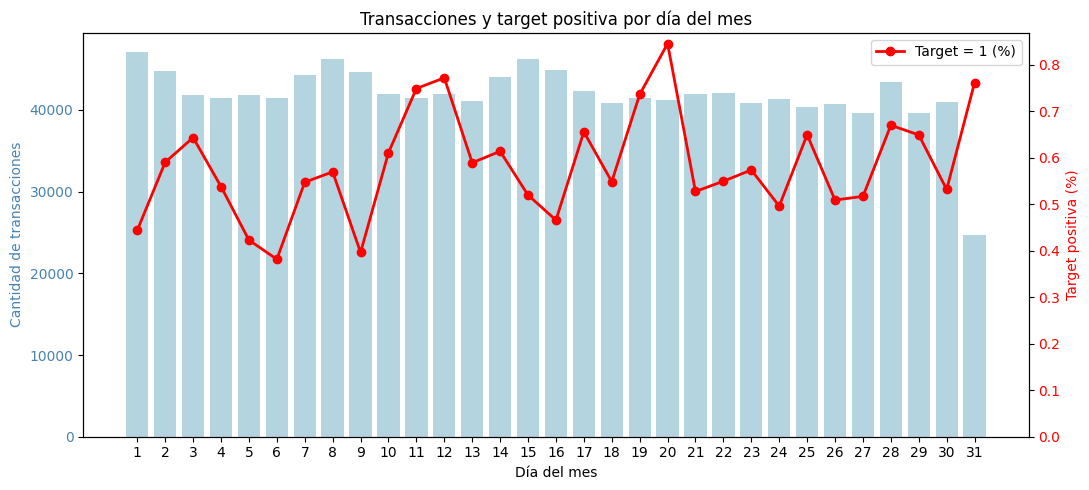

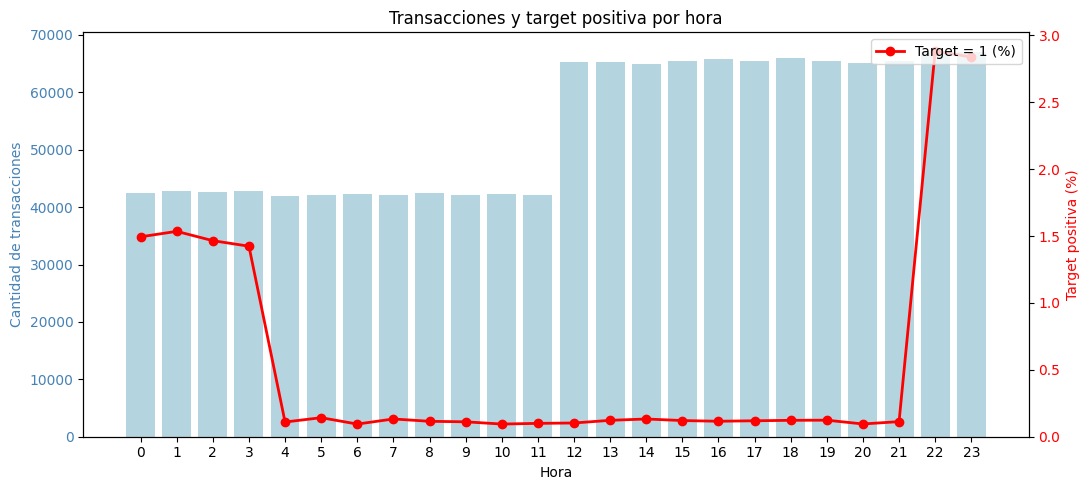

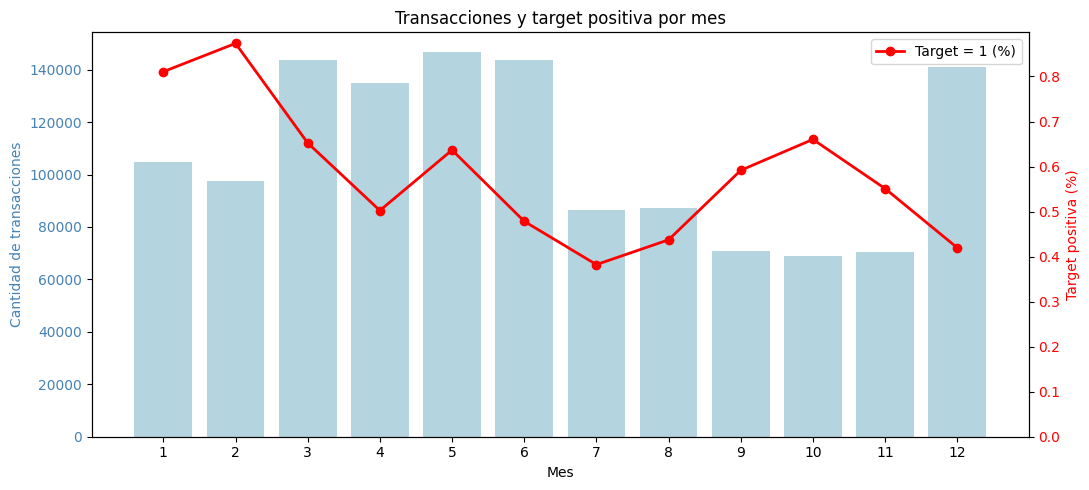

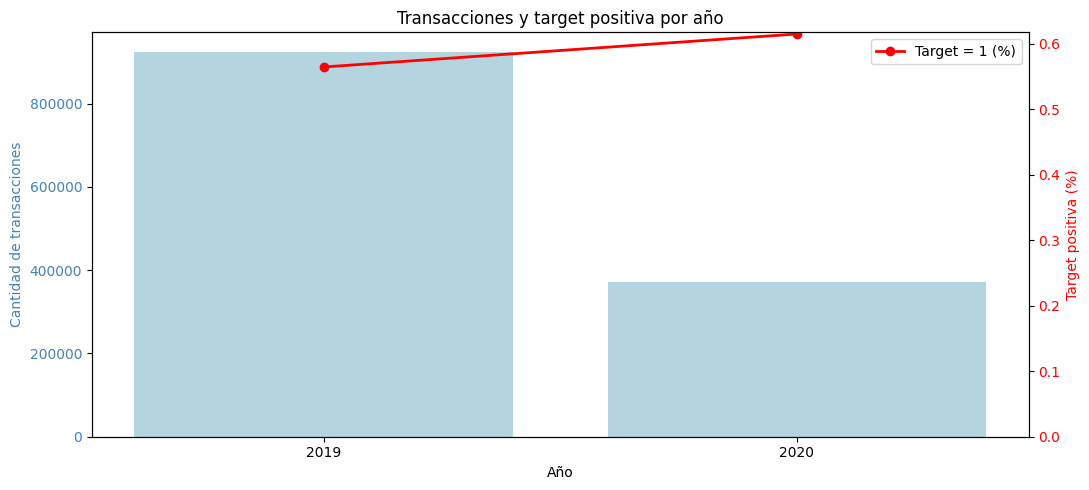

In [53]:
grafico_temporal(
    df, 'day',
    'Transacciones y target positiva por día del mes',
    'Día del mes'
)

grafico_temporal(
    df, 'hour',
    'Transacciones y target positiva por hora',
    'Hora'
)

grafico_temporal(
    df, 'month',
    'Transacciones y target positiva por mes',
    'Mes'
)

grafico_temporal(
    df, 'year',
    'Transacciones y target positiva por año',
    'Año'
)

## Porcentaje de fraude en variables seleccionadas

La tabla muestra la cantidad total de operaciones, la cantidad de fraudes y el porcentaje de fraude de cada variable. Se ordena primero por porcentaje y luego por cantidad de operaciones.

In [54]:
fraude_por_merchant = (
    df.groupby("merchant", as_index=False)
      .agg(
          total_operaciones=("is_fraud", "size"),
          cantidad_fraudes=("is_fraud", "sum"),
          tasa_fraude=("is_fraud", "mean"),
      )
)

fraude_por_merchant["porcentaje_fraude"] = (
    fraude_por_merchant["tasa_fraude"] * 100
).round(2)

fraude_por_merchant = fraude_por_merchant.sort_values(
    ["porcentaje_fraude", "total_operaciones"],
    ascending=[False, False],
).reset_index(drop=True)

fraude_por_merchant[[
    "merchant",
    "total_operaciones",
    "cantidad_fraudes",
    "porcentaje_fraude",
]].head(20)

,merchant,total_operaciones,cantidad_fraudes,porcentaje_fraude
0,fraud_Kozey-Boehm,1866,48,2.57
1,"fraud_Herman, Treutel and Dickens",1300,33,2.54
2,fraud_Kerluke-Abshire,1838,41,2.23
3,fraud_Brown PLC,1176,26,2.21
4,fraud_Goyette Inc,1943,42,2.16
5,fraud_Terry-Huel,1996,43,2.15
6,fraud_Jast Ltd,1953,42,2.15
7,"fraud_Schmeler, Bashirian and Price",1968,41,2.08
8,fraud_Boyer-Reichert,1908,38,1.99
9,"fraud_Langworth, Boehm and Gulgowski",1969,39,1.98


In [55]:
analizar_fraude_por_variable(df, 'category', top=15)

,category,total_operaciones,cantidad_fraudes,porcentaje_fraude
0,shopping_net,97543,1713,1.76
1,misc_net,63287,915,1.45
2,grocery_pos,123638,1743,1.41
3,shopping_pos,116672,843,0.72
4,gas_transport,131659,618,0.47
5,misc_pos,79655,250,0.31
6,grocery_net,45452,134,0.29
7,travel,40507,116,0.29
8,entertainment,94014,233,0.25
9,personal_care,90758,220,0.24


## Analisis de Amount

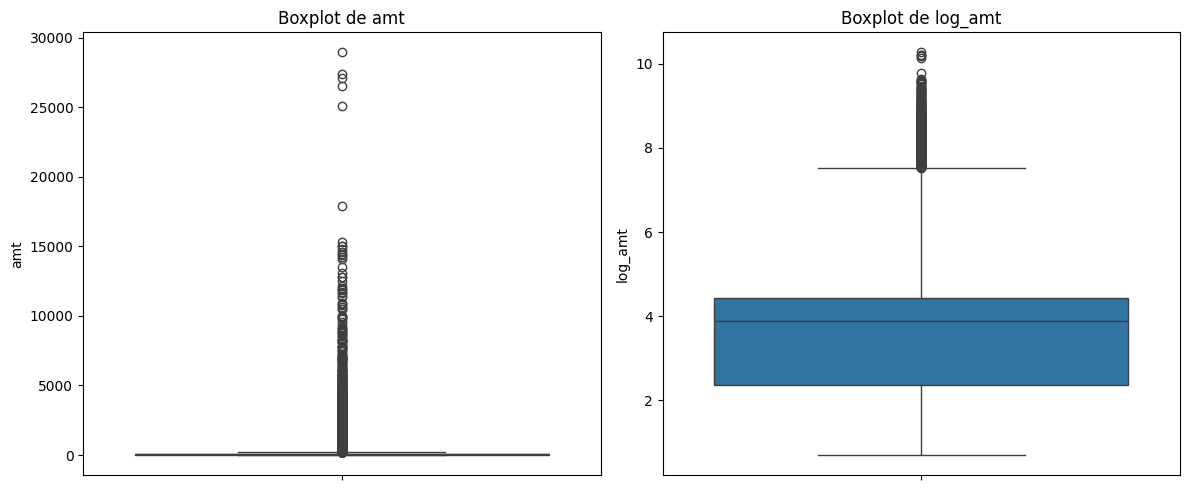

In [56]:
# Convertir amt a número y eliminar valores inválidos
df['amt'] = pd.to_numeric(df['amt'], errors='coerce')
df['log_amt'] = df['amt'].apply(lambda x: np.log(x + 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, y='amt', ax=axes[0])
axes[0].set_title('Boxplot de amt')

sns.boxplot(data=df, y='log_amt', ax=axes[1])
axes[1].set_title('Boxplot de log_amt')

plt.tight_layout()
plt.show()

## Analisis de Age

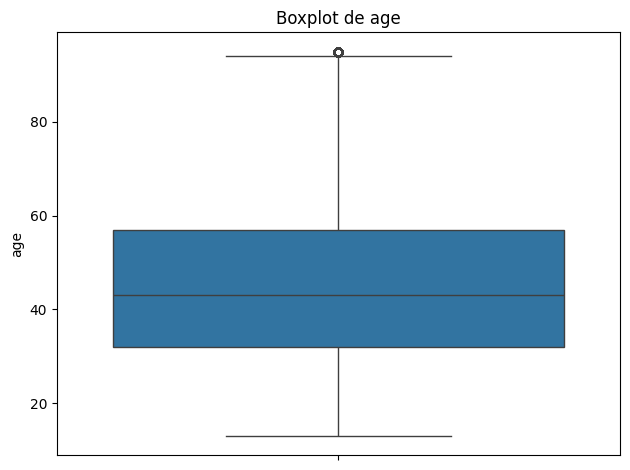

In [57]:
df['dob'] = pd.to_datetime(
    df['dob'],
    errors='coerce'
)
df['age'] = (
    (df['trans_date_trans_time'] - df['dob']).dt.days / 365.25
).astype(int)

sns.boxplot(data=df, y='age')
plt.title('Boxplot de age')

plt.tight_layout()
plt.show()

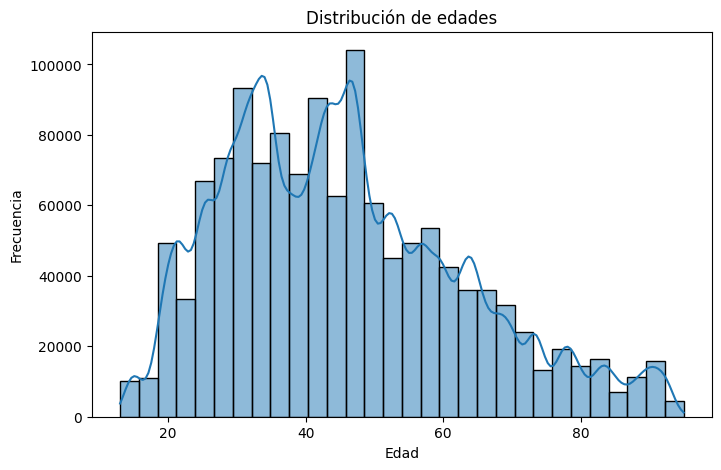

In [58]:


plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='age', bins=30, kde=True)

plt.title('Distribución de edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

## Analisis a nivel cliente
Armamos un cust id en funcion del nombre el apellido y la edad

In [59]:
cliente = (
    df['first'].fillna('').str.strip().str.lower() + '_' +
    df['last'].fillna('').str.strip().str.lower() + '_' +
    df['dob'].astype(str)
)

# Asignar un ID numérico a cada cliente
df['cust_id'] = pd.factorize(cliente)[0] + 1

df[['cust_id', 'first', 'last', 'dob']].head()

,cust_id,first,last,dob
0,1,Jennifer,Banks,1988-03-09
1,2,Stephanie,Gill,1978-06-21
2,3,Edward,Sanchez,1962-01-19
3,4,Jeremy,White,1967-01-12
4,5,Tyler,Garcia,1986-03-28


In [60]:
analizar_fraude_por_variable(df, 'cust_id')

,cust_id,total_operaciones,cantidad_fraudes,porcentaje_fraude
0,921,19,19,100.0
1,929,15,15,100.0
2,940,15,15,100.0
3,948,15,15,100.0
4,917,13,13,100.0
5,982,13,13,100.0
6,915,12,12,100.0
7,925,12,12,100.0
8,928,12,12,100.0
9,932,12,12,100.0


## Analisis de Gender 

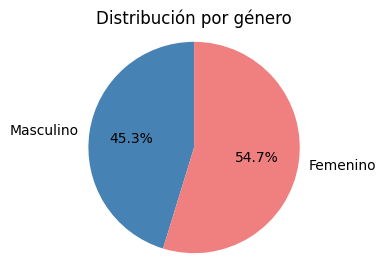

In [61]:
df['male'] = np.where(df['gender'] == 'M', 1, 0)

# Contar hombres y mujeres
conteo = df['male'].value_counts().reindex([1, 0], fill_value=0)

plt.figure(figsize=(3, 3))
plt.pie(
    conteo,
    labels=['Masculino', 'Femenino'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['steelblue', 'lightcoral']
)

plt.title('Distribución por género')
plt.axis('equal')
plt.show()

## Analisis geografico

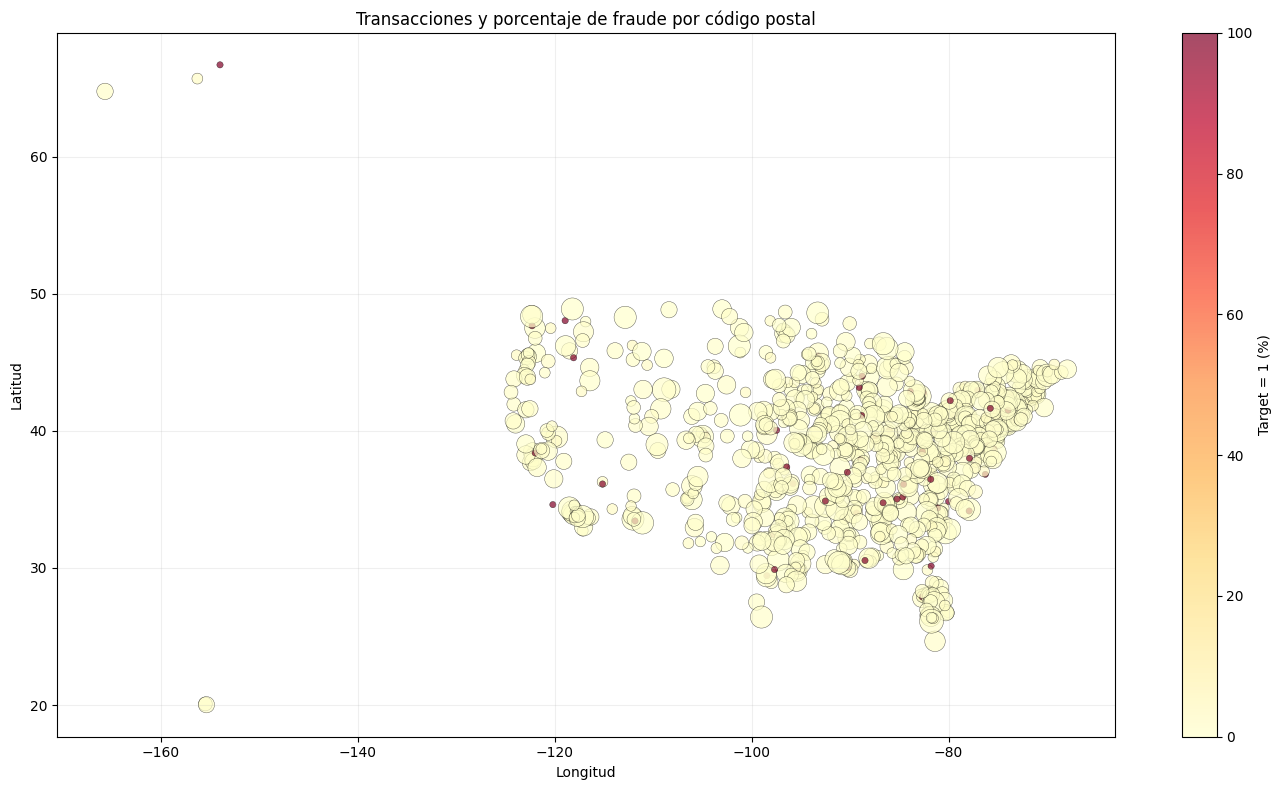

In [62]:
# Resumen por código postal
mapa_zip = (
    df.dropna(subset=['zip', 'lat', 'long'])
      .groupby('zip')
      .agg(
          lat=('lat', 'median'),
          long=('long', 'median'),
          transacciones=(target_col, 'size'),
          target_pct=(target_col, 'mean')
      )
      .reset_index()
)
mapa_zip['target_pct'] *= 100
# Ajustar el tamaño de los puntos
tamanio = (
    20
    + 280
    * mapa_zip['transacciones']
    / mapa_zip['transacciones'].max()
)
# Crear mapa estático
plt.figure(figsize=(14, 8))
puntos = plt.scatter(
    mapa_zip['long'],
    mapa_zip['lat'],
    s=tamanio,
    c=mapa_zip['target_pct'],
    cmap='YlOrRd',
    alpha=0.7,
    edgecolors='black',
    linewidths=0.3
)
cbar = plt.colorbar(puntos)
cbar.set_label('Target = 1 (%)')
plt.title('Transacciones y porcentaje de fraude por código postal')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [63]:
df['dif_lat']= (df['lat'] - df['merch_lat']).abs()
df['dif_long']= (df['long'] - df['merch_long']).abs() 

resultado = fraude_por_deciles(df, 'dif_lat')
resultado

,decil,valor_minimo,valor_maximo,total_operaciones,cantidad_fraudes,porcentaje_fraude
0,1,0.000000,0.100057,129668,704,0.54
1,2,0.100059,0.200464,129667,789,0.61
2,3,0.200467,0.300546,129669,717,0.55
3,4,0.300548,0.400426,129666,750,0.58
4,5,0.400428,0.500557,129669,740,0.57
5,6,0.500558,0.600460,129666,782,0.60
6,7,0.600463,0.700019,129667,795,0.61
7,8,0.700019,0.800004,129668,745,0.57
8,9,0.800006,0.900105,129667,741,0.57
9,10,0.900106,0.999999,129668,743,0.57


In [64]:
analizar_fraude_por_variable(df, 'dif_long')

,dif_long,total_operaciones,cantidad_fraudes,porcentaje_fraude
0,0.038205,2,2,100.0
1,0.071796,2,2,100.0
2,0.388115,2,2,100.0
3,0.524347,2,2,100.0
4,0.567907,2,2,100.0
5,0.815851,2,2,100.0
6,0.000438,1,1,100.0
7,0.000502,1,1,100.0
8,0.000725,1,1,100.0
9,0.001463,1,1,100.0


In [65]:
analizar_fraude_por_variable(df, 'dif_lat')

,dif_lat,total_operaciones,cantidad_fraudes,porcentaje_fraude
0,0.000334,1,1,100.0
1,0.000481,1,1,100.0
2,0.001341,1,1,100.0
3,0.001379,1,1,100.0
4,0.001590,1,1,100.0
5,0.001648,1,1,100.0
6,0.002193,1,1,100.0
7,0.002258,1,1,100.0
8,0.002523,1,1,100.0
9,0.002701,1,1,100.0


## Analisis de la Ley de Benford

In [66]:
# La guia de Nigrini recomienda excluir importes menores que 10
# y analizar por separado los valores positivos y negativos.
df_benford = df.loc[df["amt"] >= 10].copy()
x = df_benford["amt"]

# Dígitos significativos
mantisa = x / (10 ** np.floor(np.log10(x)))

df_benford["primer_digito"] = np.floor(mantisa).astype(int)

# Redondeamos
df_benford["primeros_2"] = np.floor((mantisa * 10).round(10)).astype(int)
df_benford["segundo_digito"] = df_benford["primeros_2"] % 10
df_benford["primeros_3"] = np.floor((mantisa * 100).round(10)).astype(int)

# Últimos dos dígitos del importe, incluyendo centavos
df_benford["ultimos_2"] = (
    np.rint(x * 100).astype("int64") % 100
)
''' Primer dígito, segundo dígito, primeros dos y primeros tres: se derivan de la Ley de Benford.
Últimos dos dígitos: se comparan con una distribución uniforme del 1%, no con la fórmula principal de Benford.'''


def probabilidades_benford(tipo, valores):
    valores = np.asarray(valores)

    if tipo in ["primer_digito", "primeros_2", "primeros_3"]:
        return np.log10(1 + 1 / valores)

    if tipo == "segundo_digito":
        return np.array([
            sum(np.log10(1 + 1 / (10 * k + d)) for k in range(1, 10))
            for d in valores
        ])

    # En el test de últimos dos dígitos se espera 1% para cada combinación
    return np.repeat(0.01, len(valores))


tests = {
    "primer_digito": range(1, 10),
    "segundo_digito": range(10),
    "primeros_2": range(10, 100),
    "primeros_3": range(100, 1000),
    "ultimos_2": range(100)
}

# Incluimos los cinco tests en las alertas exploratorias.
# Primer y segundo digito generan alertas mas amplias; la guia los usa
# como tests globales. Incluirlos en la seleccion es una decision propia.
tests_seleccion = {
    "primer_digito", "segundo_digito",
    "primeros_2", "primeros_3", "ultimos_2"
}
resultados_tests = []

df_benford["benford_score"] = 0.0
df_benford["tests_sospechosos"] = 0

for columna, valores in tests.items():
    valores = list(valores)
    n = len(df_benford)

    observado = (
        df_benford[columna]
        .value_counts()
        .reindex(valores, fill_value=0)
    )

    prob_esperada = probabilidades_benford(columna, valores)
    proporcion_observada = observado / n
    diferencia = proporcion_observada - prob_esperada

    # Restar la correccion solo si es menor que la diferencia absoluta.
    diferencia_absoluta = diferencia.abs()
    correccion = 1 / (2 * n)
    numerador = diferencia_absoluta.where(
        diferencia_absoluta <= correccion, diferencia_absoluta - correccion
    )
    z = (
        numerador
        / np.sqrt(prob_esperada * (1 - prob_esperada) / n)
    )

    resultados_tests.append(pd.DataFrame({
        "test": columna,
        "valor": valores,
        "observada": proporcion_observada.values,
        "esperada": prob_esperada,
        "diferencia": diferencia.values,
        "Z": z.values
    }))

    resumen_benford = pd.concat(resultados_tests, ignore_index=True)

    

In [67]:
resumen_benford


,test,valor,observada,esperada,diferencia,Z
0,primer_digito,1,0.275650,0.301030,-0.025380,54.237148
1,primer_digito,2,0.113967,0.176091,-0.062125,159.883600
2,primer_digito,3,0.092824,0.124939,-0.032115,95.209378
3,primer_digito,4,0.099944,0.096910,0.003034,10.052134
4,primer_digito,5,0.105421,0.079181,0.026240,95.258569
...,...,...,...,...,...,...
1104,ultimos_2,95,0.009854,0.010000,-0.000146,1.436070
1105,ultimos_2,96,0.009924,0.010000,-0.000076,0.738899
1106,ultimos_2,97,0.009969,0.010000,-0.000031,0.298041
1107,ultimos_2,98,0.009984,0.010000,-0.000016,0.154505


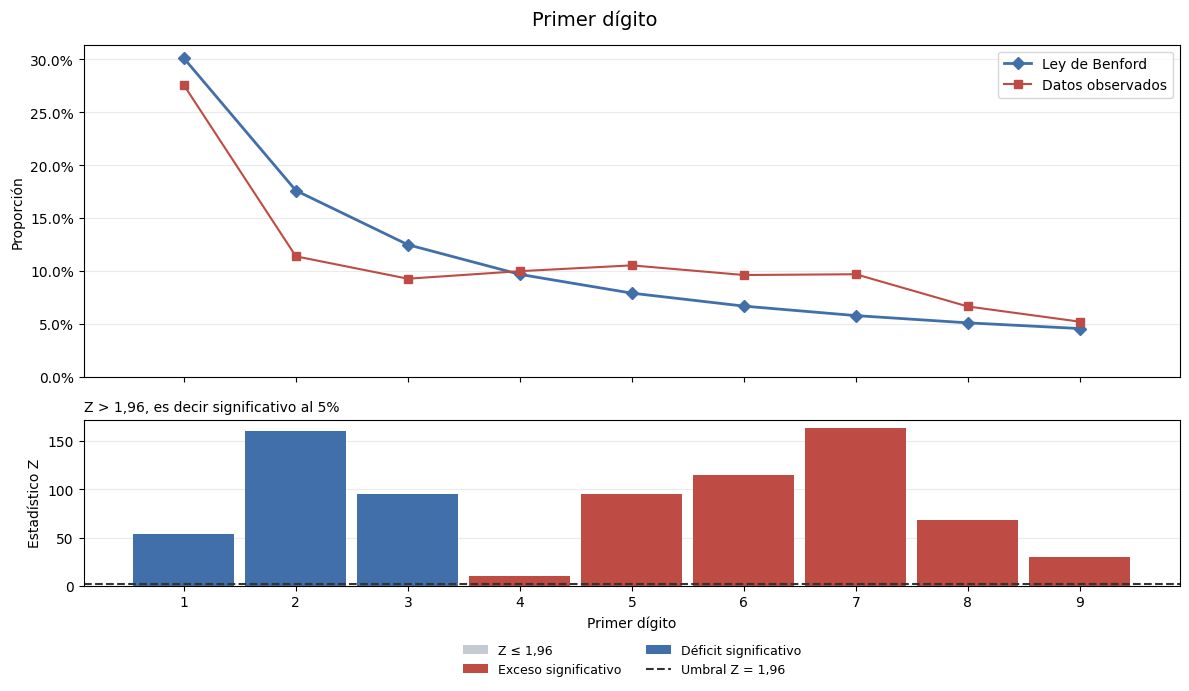

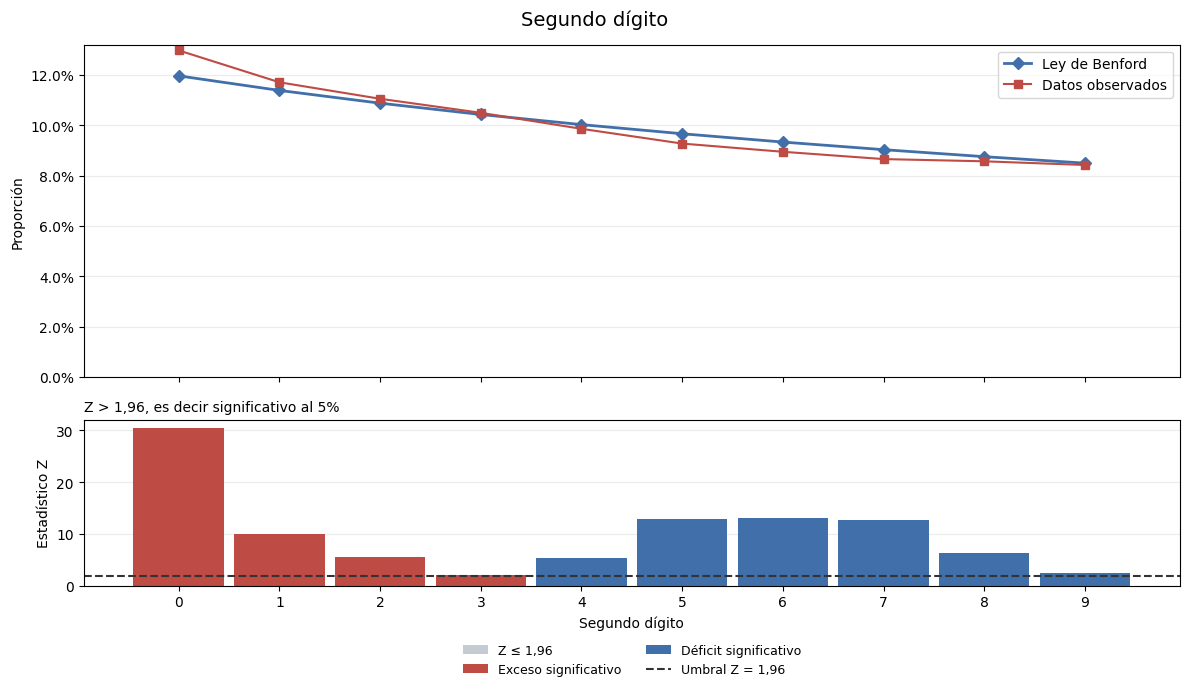

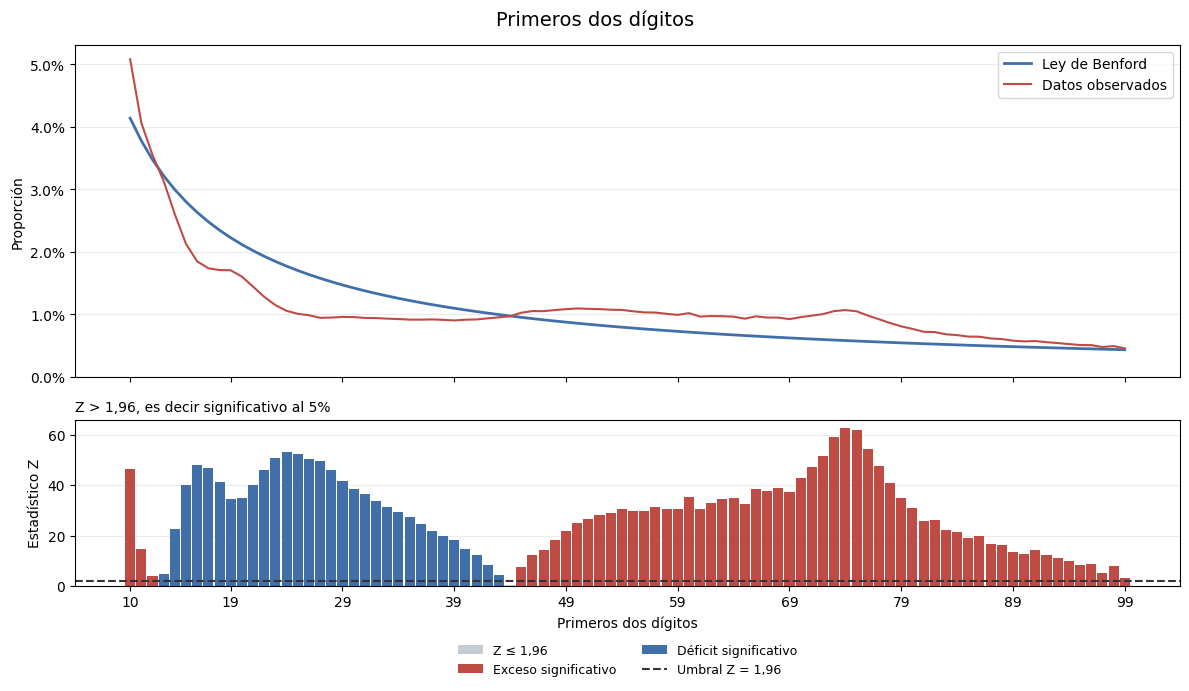

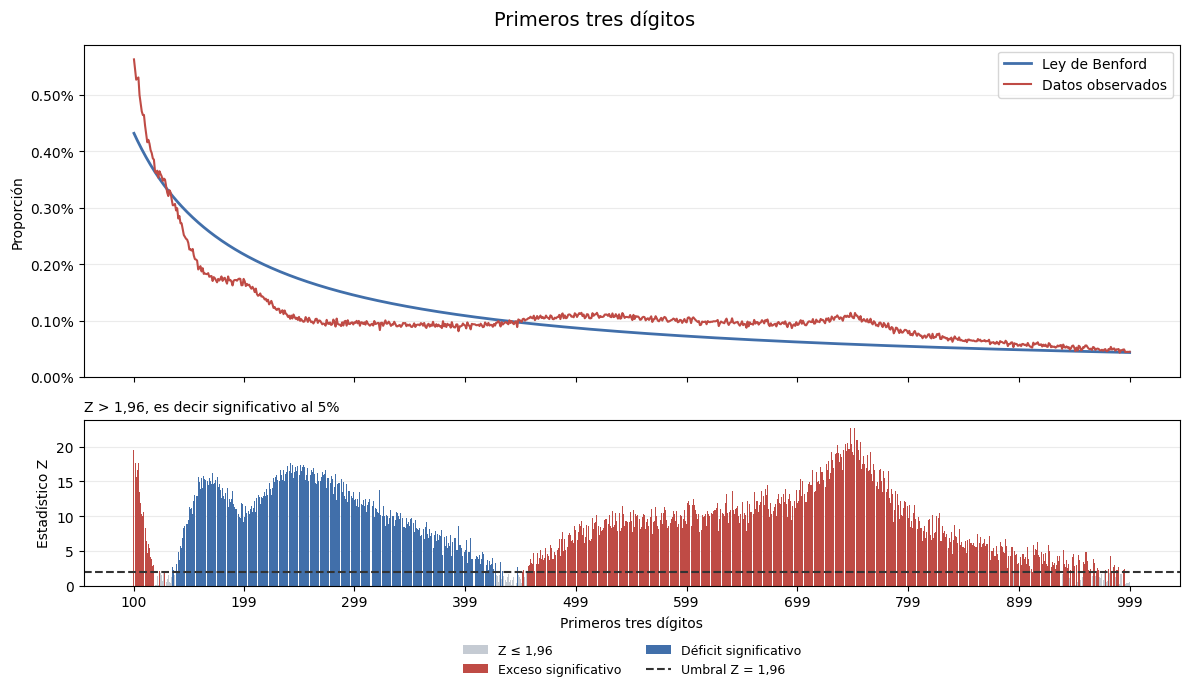

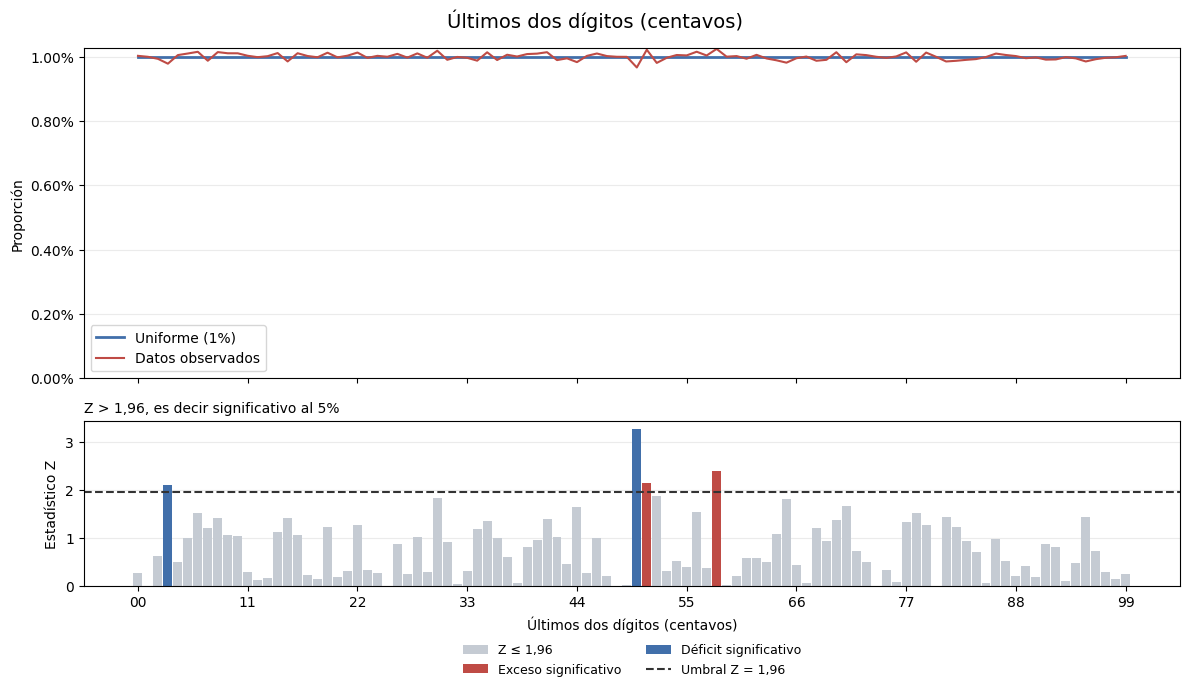

In [68]:



def graficar_benford(tipo, rango=None):
    """Compara proporciones y Z. rango=(300, 399) amplía esa parte del gráfico."""
    datos = resumen_benford.loc[resumen_benford["test"] == tipo].copy()
    if rango is not None:
        # Solo cambia la vista: las frecuencias y el Z usan toda la muestra.
        datos = datos.loc[datos["valor"].between(rango[0], rango[1])]
    datos = datos.sort_values("valor")
    if datos.empty:
        raise ValueError("No hay resultados para ese test o rango.")

    titulos = {
        "primer_digito": "Primer dígito",
        "segundo_digito": "Segundo dígito",
        "primeros_2": "Primeros dos dígitos",
        "primeros_3": "Primeros tres dígitos",
        "ultimos_2": "Últimos dos dígitos (centavos)"
    }
    azul = "#416faa"
    rojo = "#bf4b45"
    gris = "#c5cbd3"
    negro = "#333333"
    valores = datos["valor"]
    significativo = datos["Z"] > 1.96
    exceso = significativo & (datos["diferencia"] > 0)
    deficit = significativo & (datos["diferencia"] < 0)

    fig, (ax_prop, ax_z) = plt.subplots(
        2, 1, figsize=(12, 7), sharex=True,
        gridspec_kw={"height_ratios": [2, 1]}
    )
    fig.suptitle(
        f"{titulos[tipo]}", fontsize=14
    )

    # Panel superior: frecuencias observadas y teóricas.
    etiqueta_teorica = "Uniforme (1%)" if tipo == "ultimos_2" else "Ley de Benford"
    ax_prop.plot(
        valores, datos["esperada"], color=azul, linewidth=2,
        marker="D" if len(datos) <= 10 else None, label=etiqueta_teorica
    )
    ax_prop.plot(
        valores, datos["observada"], color=rojo, linewidth=1.5,
        marker="s" if len(datos) <= 10 else None, label="Datos observados"
    )
    ax_prop.set_ylabel("Proporción")
    ax_prop.yaxis.set_major_formatter(PercentFormatter(1))
    ax_prop.set_ylim(bottom=0)
    ax_prop.legend()

    # Panel inferior: magnitud del Z y dirección de la desviación.
    ax_z.bar(valores, datos["Z"], color=gris, label="Z ≤ 1,96", width=0.9)
    ax_z.bar(valores[exceso], datos.loc[exceso, "Z"],
             color=rojo, label="Exceso significativo", width=0.9)
    ax_z.bar(valores[deficit], datos.loc[deficit, "Z"],
             color=azul, label="Déficit significativo", width=0.9)
    linea_umbral = ax_z.axhline(
        1.96, color=negro, linestyle="--", label="Umbral Z = 1,96"
    )
    ax_z.set_title(
        f"Z > 1,96, es decir significativo al 5%",
        fontsize=10, loc="left"
    )
    ax_z.set_ylabel("Estadístico Z")
    ax_z.set_xlabel(titulos[tipo])
    ax_z.set_ylim(bottom=0)
    ax_z.legend(handles=[
        Patch(facecolor=gris, label="Z ≤ 1,96"),
        Patch(facecolor=rojo, label="Exceso significativo"),
        Patch(facecolor=azul, label="Déficit significativo"),
        linea_umbral
    ], loc="upper center", bbox_to_anchor=(0.5, -0.28),
       ncol=2, frameon=False, fontsize=9)

    # Con muchas categorías, reducir etiquetas sin ocultar los datos.
    marcas = valores.to_numpy() if len(datos) <= 10 else np.linspace(
        valores.min(), valores.max(), 10, dtype=int
    )
    etiquetas = [f"{v:02d}" if tipo == "ultimos_2" else str(v) for v in marcas]
    ax_z.set_xticks(marcas, etiquetas)
    for ax in (ax_prop, ax_z):
        ax.set_axisbelow(True)
        ax.grid(axis="y", alpha=0.25)

    # El umbral es por categoría; con N grande, desvíos pequeños pueden superarlo.
    fig.tight_layout()
    plt.show()


# Generar los cinco gráficos usando los resultados ya calculados.
for tipo in tests:
    graficar_benford(tipo)

# Para ampliar una zona del test de tres dígitos, por ejemplo:
# graficar_benford("primeros_3", rango=(300, 399))


La metodología distingue los tests según su finalidad:
- Primer dígito: evaluación general.
- Segundo dígito: evaluación general.
- Primeros dos dígitos: selección de grupos para revisión.
- Primeros tres dígitos: selección más específica.
- Últimos dos dígitos: detección de redondeos.

Por eso elegimos el test: primeros dos

In [69]:
grupos_prioritarios

,test,valor,observada,esperada,diferencia,Z
83,primeros_2,74,0.010707,0.005830,0.004877,62.799245
84,primeros_2,75,0.010517,0.005752,0.004764,61.749270


In [70]:
# Usamos primeros dos dígitos para priorizar operaciones
test_priorizacion = "primeros_2"
cantidad_grupos = 2 ## son los grupos que vamos a priorizar para investigacion de fraude

# Grupos sobrerrepresentados y estadísticamente significativos
''' Tomas los diez grupos de primeros dos dígitos con mayor desviación
 positiva y cuyo Z supere 1.96”'''
grupos_prioritarios = resumen_benford[
    (resumen_benford["test"] == test_priorizacion)
    & (resumen_benford["diferencia"] > 0) # nos quedamos por las positivas, que son las sobrerrepresentadas
    & (resumen_benford["Z"] > 1.96)
].nlargest(cantidad_grupos, "Z")

# Relacionamos cada grupo con su estadístico Z
score_por_grupo = grupos_prioritarios.set_index("valor")["Z"]

# Cada operación recibe el Z de su grupo
df_benford["benford_score"] = (
    df_benford[test_priorizacion]
    .map(score_por_grupo)
    .fillna(0)
)

candidatas_benford = (
    df_benford[df_benford["benford_score"] > 0]
    .sort_values("benford_score", ascending=False)
)

columnas_resultado = [
    "trans_num",
    "trans_date_trans_time",
    "merchant",
    "amt",
    "primeros_2",
    "benford_score"
]

candidatas_benford[columnas_resultado].head(10)

,trans_num,trans_date_trans_time,merchant,amt,primeros_2,benford_score
650297,eee64720672e781269200ad14ed1116a,2019-10-04 09:09:22,fraud_Huels-Nolan,74.95,74,62.799245
725242,edb37d43aec3f8355ecc6821efabe0c8,2019-11-05 17:17:53,"fraud_Klocko, Runolfsdottir and Breitenberg",74.57,74,62.799245
725471,904ccb9938e0b021b63d264593c137bb,2019-11-05 20:23:20,fraud_Jacobi Inc,74.03,74,62.799245
725564,6a68438f0475e5b441a6c10e90f02fa8,2019-11-05 21:21:24,fraud_Spencer PLC,74.59,74,62.799245
725778,6533be8ba50831d0ba56cd065cab1d86,2019-11-06 00:15:37,fraud_Cummings LLC,74.22,74,62.799245
725783,74b1bcf8224dcff89a73fd8ef2915019,2019-11-06 00:22:16,fraud_Parisian and Sons,74.39,74,62.799245
725876,4d69018279985fa2e181eb1e2a2b9ee9,2019-11-06 02:05:32,fraud_Brekke and Sons,74.84,74,62.799245
726035,347dfb3c848b0b537cd2283f47b15cae,2019-11-06 05:14:33,fraud_Kilback LLC,74.28,74,62.799245
726043,c348d96e01b81ac1d17648f2caad72ad,2019-11-06 05:20:54,"fraud_Schaefer, McGlynn and Bosco",74.37,74,62.799245
726355,25cdf1c0f8907869e71f6727963bd48b,2019-11-06 10:57:49,"fraud_Connelly, Reichert and Fritsch",74.30,74,62.799245


In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


def evaluar_flags_fraude(flag_real, flag_predicho):
    """Calcula métricas de clasificación para flags binarios de fraude (0/1)."""
    y_real = pd.Series(flag_real).reset_index(drop=True)
    y_predicho = pd.Series(flag_predicho).reset_index(drop=True)

    if len(y_real) != len(y_predicho):
        raise ValueError("Los flags reales y predichos deben tener la misma longitud.")
    if y_real.isna().any() or y_predicho.isna().any():
        raise ValueError("Los flags no pueden contener valores faltantes.")
    if not set(y_real.unique()).issubset({0, 1}):
        raise ValueError("El flag real debe contener solamente 0 y 1.")
    if not set(y_predicho.unique()).issubset({0, 1}):
        raise ValueError("El flag predicho debe contener solamente 0 y 1.")

    return pd.DataFrame({
        "metrica": ["accuracy", "precision", "recall", "f1"],
        "valor": [
            accuracy_score(y_real, y_predicho),
            precision_score(y_real, y_predicho, zero_division=0),
            recall_score(y_real, y_predicho, zero_division=0),
            f1_score(y_real, y_predicho, zero_division=0),
        ],
    }).set_index("metrica")


# Evaluamos la alerta de Benford como un clasificador binario:
# 1 si la operación pertenece a un grupo prioritario; 0 en caso contrario.
metricas_benford = evaluar_flags_fraude(
    flag_real=df_benford["is_fraud"],
    flag_predicho=(df_benford["benford_score"] > 0).astype(int),
)

metricas_benford

,valor
metrica,
accuracy,0.971822
precision,0.007306
recall,0.021344
f1,0.010885


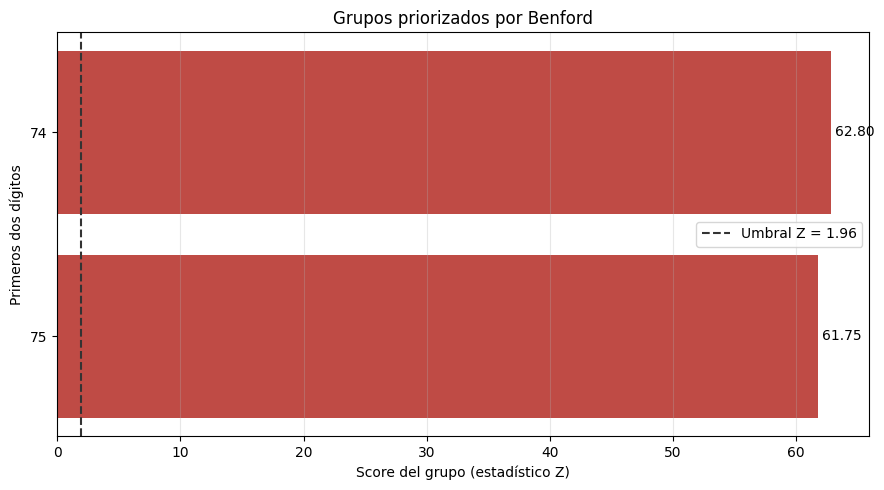

In [72]:
def graficar_score_benford(grupos_prioritarios):
    datos = grupos_prioritarios.sort_values("Z")

    fig, ax = plt.subplots(figsize=(9, 5))

    barras = ax.barh(
        datos["valor"].astype(str),
        datos["Z"],
        color="#bf4b45"
    )

    ax.axvline(
        1.96,
        color="#333333",
        linestyle="--",
        label="Umbral Z = 1.96"
    )

    ax.bar_label(
        barras,
        labels=[f"{z:.2f}" for z in datos["Z"]],
        padding=3
    )

    ax.set_title("Grupos priorizados por Benford")
    ax.set_xlabel("Score del grupo (estadístico Z)")
    ax.set_ylabel("Primeros dos dígitos")
    ax.grid(axis="x", alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

graficar_score_benford(grupos_prioritarios)

## Hacemos Benford sobre Test

In [73]:
csv_path = Path("../fraudTest.csv")
df_test = pd.read_csv(csv_path)

In [74]:
df_test

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,...,40.4931,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0
555715,555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,...,29.0393,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
555716,555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,...,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
555717,555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,...,44.6255,-116.4493,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0


In [75]:
grupos_entrenados = grupos_prioritarios["valor"]

mantisa_test = (
    df_test["amt"]
    / (10 ** np.floor(np.log10(df_test["amt"])))
)

primeros_2_test = np.floor(
    (mantisa_test * 10).round(10)
).astype(int)

df_test["benford_score"] = (
    df_test["amt"].ge(10)
    & primeros_2_test.isin(grupos_entrenados)
).astype(int)

In [76]:
df_test['flag_benford'] = np.where(df_test['benford_score'] > 0, 1, 0)



In [77]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd


def evaluar_fraude(flag_real, flag_predicho):
    return pd.DataFrame({
        "Métrica": ["Accuracy", "Precision", "Recall", "F1"],
        "Valor": [
            accuracy_score(flag_real, flag_predicho),
            precision_score(flag_real, flag_predicho, zero_division=0),
            recall_score(flag_real, flag_predicho, zero_division=0),
            f1_score(flag_real, flag_predicho, zero_division=0)
        ]
    })


# Ejemplo con las alertas de Benford
metricas = evaluar_fraude(
    flag_real=df_test["is_fraud"],
    flag_predicho=(df_test["flag_benford"]))

metricas

,Métrica,Valor
0,Accuracy,0.980857
1,Precision,0.003971
2,Recall,0.015851
3,F1,0.006352


In [ ]:
matriz = confusion_matrix(df_test["is_fraud"],df_test["flag_benford"],labels=[0, 1])
tn, fp, fn, tp = matriz.ravel()
print(f"Verdaderos Negativos: {tn}")
print(f"Falsos Positivos: {fp}")
print(f"Falsos Negativos: {fn}") 
print(f"Verdaderos Positivos: {tp}") 
print(matriz)

Verdaderos Negativos: 545047
Falsos Positivos: 8527
Falsos Negativos: 2111
Verdaderos Positivos: 34
[[545047   8527]
 [  2111     34]]


## Feature eng

In [78]:
def feature_engeneering(df, features):
    df = df.copy()
    df['trans_date_trans_time'] = pd.to_datetime(
        df['trans_date_trans_time'],
        errors='coerce'
    )
    df['day'] = df['trans_date_trans_time'].dt.day
    df['month'] = df['trans_date_trans_time'].dt.month
    df['year'] = df['trans_date_trans_time'].dt.year
    df['hour'] = df['trans_date_trans_time'].dt.hour
    df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
    df['night_flag'] = np.where((df['hour'].isin([22, 23, 0, 1, 2, 3])) , 1, 0)
    df['log_amt'] = df['amt'].apply(lambda x: np.log(x + 1))
    df['dob'] = pd.to_datetime(
        df['dob'],
        errors='coerce'
    )
    df['age'] = ((df['trans_date_trans_time'] - df['dob']).dt.days / 365.25).astype(int)
    df['male'] = np.where(df['gender'] == 'M', 1, 0)
    df['dif_lat']= (df['lat'] - df['merch_lat']).abs()
    df['dif_long']= (df['long'] - df['merch_long']).abs() 
    ## one hot encodign de categorys
    df = pd.get_dummies(df,columns=['category'],prefix='category',drop_first=True,dtype=int)

    # Variables de Benford calculadas fila por fila
    mantisa = df["amt"] / (10 ** np.floor(np.log10(df["amt"])))


    df["primeros_2"] = np.floor(
        (mantisa * 10).round(10)
    ).astype(int)

    df["benford_prob_2d"] = np.log10(
        1 + 1 / df["primeros_2"])

    df["benford_surprisal_2d"] = -np.log(df["benford_prob_2d"])

    
    df = df[features + ['is_fraud']]
    
    return df


In [79]:
features = ['day', 'month', 'year', 'hour', 'day_of_week', 'night_flag', 'amt',
                'log_amt', 'age', 'male', 'dif_lat', 'dif_long', 'city_pop', 

    # one hot encodign de categoria
    'category_food_dining',
    'category_gas_transport',
    'category_grocery_net',
    'category_grocery_pos',
    'category_health_fitness',
    'category_home',
    'category_kids_pets',
    'category_misc_net',
    'category_misc_pos',
    'category_personal_care',
    'category_shopping_net',
    'category_shopping_pos',
    'category_travel',

      # Benford
    #'primeros_2',
    'benford_surprisal_2d',
]
df = pd.read_csv(csv_path)
df = feature_engeneering(df, features)
train_model_sin_target = df.drop(columns=['is_fraud'])

In [80]:
train_model_sin_target[['amt', 'benford_surprisal_2d']].sort_values('benford_surprisal_2d', ascending=False).head(10)

,amt,benford_surprisal_2d
300346,99.59,5.434182
222045,9.94,5.434182
488413,9.95,5.434182
478915,99.56,5.434182
411375,9.94,5.434182
433340,99.68,5.434182
23474,99.96,5.434182
90215,99.37,5.434182
413680,99.92,5.434182
75561,99.27,5.434182


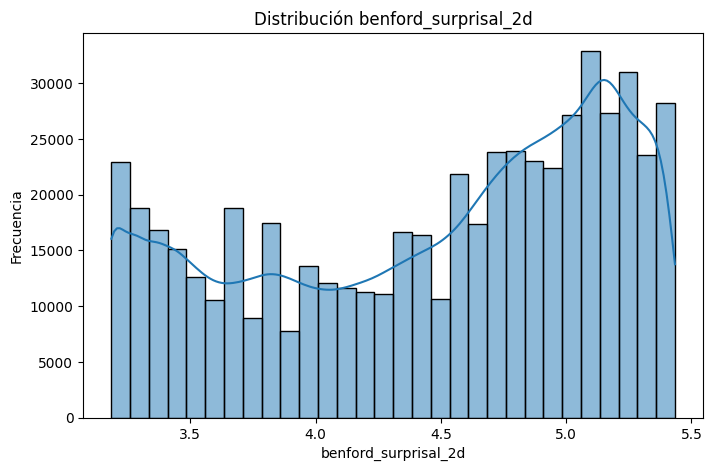

In [81]:
plt.figure(figsize=(8, 5))

sns.histplot(data=train_model_sin_target, x='benford_surprisal_2d', bins=30, kde=True)

plt.title('Distribución benford_surprisal_2d')
plt.xlabel('benford_surprisal_2d')
plt.ylabel('Frecuencia')
plt.show()

## Analisis de multicolinealidad (VIF)

In [82]:
def calcular_vif(df, variables):
    X = df[variables].dropna()

# Agrega la constante
    X = sm.add_constant(X)

    vif = pd.DataFrame({
        'variable': X.columns,
        'VIF': [
            variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])
        ]
    })

    return (
        vif[vif['variable'] != 'const']
        .sort_values('VIF', ascending=False)
        .reset_index(drop=True)
    )
resultado_vif = calcular_vif(df, features)
resultado_vif.style.format({'VIF': '{:.2f}'})


,variable,VIF
0,year,131.75
1,category_gas_transport,2.64
2,category_grocery_pos,2.52
3,category_shopping_pos,2.15
4,hour,2.11
5,category_home,2.11
6,category_kids_pets,2.04
7,category_shopping_net,1.98
8,category_personal_care,1.86
9,category_food_dining,1.84


In [83]:
train_model_sin_target.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 27 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   day                      555719 non-null  int32  
 1   month                    555719 non-null  int32  
 2   year                     555719 non-null  int32  
 3   hour                     555719 non-null  int32  
 4   day_of_week              555719 non-null  int32  
 5   night_flag               555719 non-null  int64  
 6   amt                      555719 non-null  float64
 7   log_amt                  555719 non-null  float64
 8   age                      555719 non-null  int64  
 9   male                     555719 non-null  int64  
 10  dif_lat                  555719 non-null  float64
 11  dif_long                 555719 non-null  float64
 12  city_pop                 555719 non-null  int64  
 13  category_food_dining     555719 non-null  int64  
 14  cate

## Clusters

In [84]:


features_cluster = [
    "log_amt",     # monto de la transacción
    "age",         # edad del cliente
    "dif_lat",     # distancia geográfica 
    "dif_long",
    "city_pop",    # tamaño de la ciudad
    "night_flag"   # operación nocturna
]

X_cluster = train_model_sin_target[features_cluster].copy()


scaler = StandardScaler()

scaled_data = pd.DataFrame(
    scaler.fit_transform(X_cluster),
    columns=features_cluster,
    index=X_cluster.index
)

scaled_data.head()

,log_amt,age,dif_lat,dif_long,city_pop,night_flag
0,-1.693122,0.321790,-1.662657,-0.813743,0.816521,-0.552985
1,-0.076863,-0.940243,1.281904,-0.085184,-0.292685,-0.552985
2,0.168516,0.149695,-1.119984,0.552240,-0.178853,-0.552985
3,0.454241,-0.825513,-0.892628,-1.510777,-0.111371,-0.552985
4,-1.629321,1.010171,0.713743,1.273068,-0.289942,-0.552985


,Inercia,Silhouette,Calinski-Harabasz,Davies-Bouldin,Cluster mas chico,Cluster mas grande
K,,,,,,
2,2776674.388,0.241,111604.664,1.748,130139,425580
3,2379869.558,0.258,111434.695,1.423,17994,411471
4,2070688.795,0.194,113041.318,1.604,17912,206042
5,1858270.832,0.188,110352.881,1.464,17700,143125
6,1696443.049,0.188,107305.809,1.351,17535,123368
7,1578271.281,0.180,103051.539,1.262,17400,121967
8,1483954.923,0.190,98989.480,1.404,17039,95117


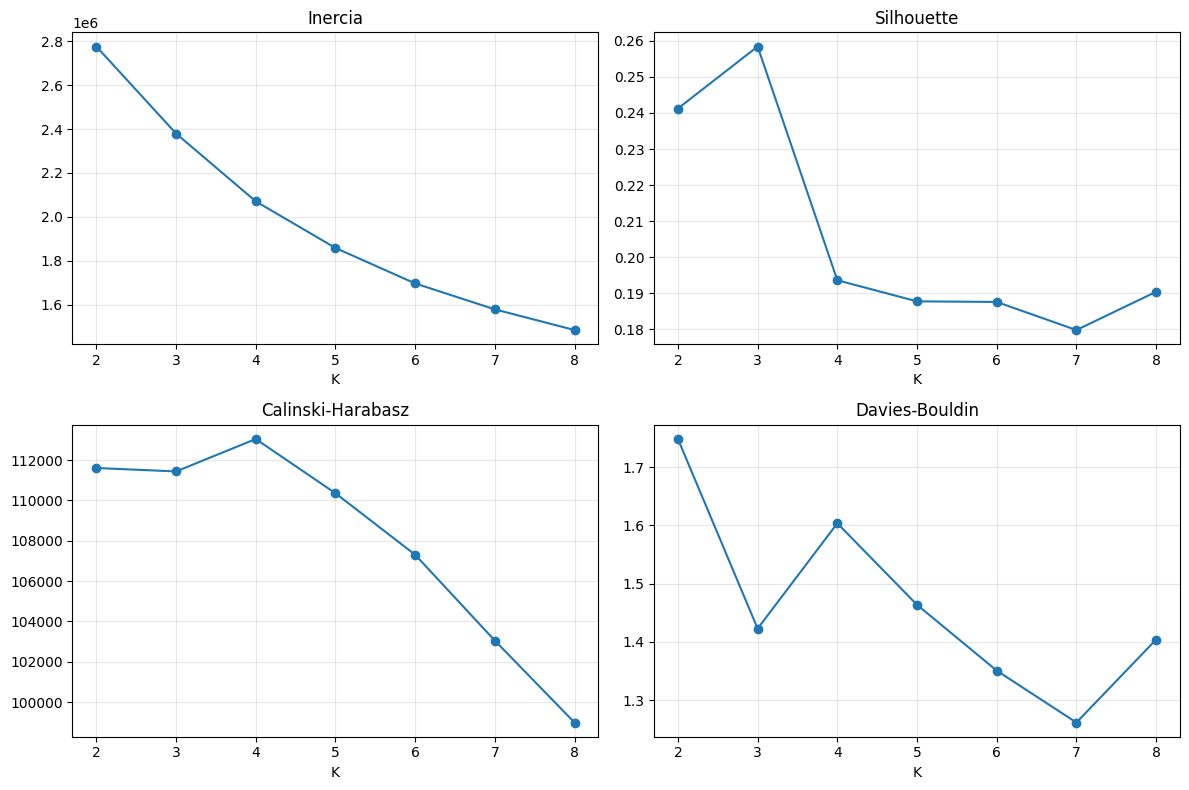

In [85]:


# Probamos varias cantidades de clusters
valores_k = range(2, 9)
resultados_k = []
labels_por_k = {}
modelos_por_k = {}

for k in valores_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = modelo.fit_predict(scaled_data)
    labels_por_k[k] = labels
    modelos_por_k[k] = modelo

    tamanos = pd.Series(labels).value_counts()

    resultados_k.append({
        'K': k,
        'Inercia': modelo.inertia_,
        'Silhouette': silhouette_score(scaled_data, labels, sample_size=10_000, random_state=42),
        'Calinski-Harabasz': calinski_harabasz_score(scaled_data, labels),
        'Davies-Bouldin': davies_bouldin_score(scaled_data, labels),
        'Cluster mas chico': tamanos.min(),
        'Cluster mas grande': tamanos.max()
    })

metricas_k = pd.DataFrame(resultados_k).set_index('K')
display(metricas_k.round(3))

# Graficos de las metricas
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

metricas_k['Inercia'].plot(marker='o', ax=axes[0, 0])
axes[0, 0].set_title('Inercia')

metricas_k['Silhouette'].plot(marker='o', ax=axes[0, 1])
axes[0, 1].set_title('Silhouette')

metricas_k['Calinski-Harabasz'].plot(marker='o', ax=axes[1, 0])
axes[1, 0].set_title('Calinski-Harabasz')

metricas_k['Davies-Bouldin'].plot(marker='o', ax=axes[1, 1])
axes[1, 1].set_title('Davies-Bouldin')

for ax in axes.flat:
    ax.set_xlabel('K')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



In [86]:
#Seleccion de K
K = 4

In [87]:
modelo = modelos_por_k[K]
labels = labels_por_k[K]

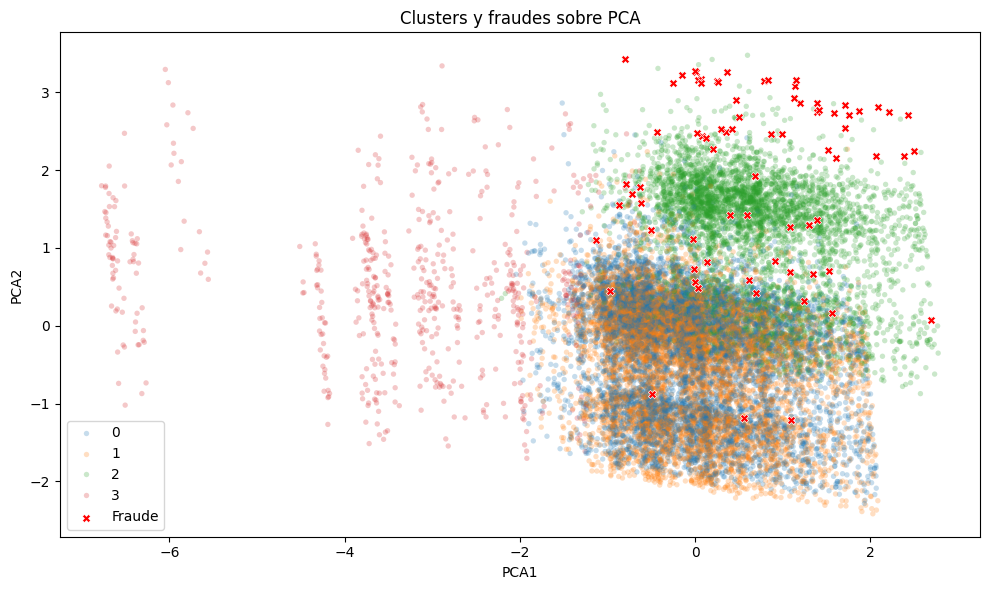

In [97]:

# Reducimos los datos a dos dimensiones
pca = PCA(n_components=2)
componentes = pca.fit_transform(scaled_data)

datos_pca = pd.DataFrame(componentes, columns=['PCA1', 'PCA2'])
datos_pca['cluster'] = labels
datos_pca['is_fraud'] = df['is_fraud'].values

# Usamos una muestra para que el grafico sea liviano
muestra = datos_pca.sample(20_000, random_state=42)
fraudes = muestra[muestra['is_fraud'] == 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=muestra, x='PCA1', y='PCA2', hue='cluster',palette='tab10', alpha=0.25, s=15, linewidth=0)
sns.scatterplot(data=fraudes, x='PCA1', y='PCA2',color='red', marker='X', s=35, label='Fraude', zorder=10)
plt.title('Clusters y fraudes sobre PCA')
plt.tight_layout()
plt.show()

In [96]:
resumen_clusters = (
    pd.DataFrame({
        'cluster': labels,
        'is_fraud': df['is_fraud'].to_numpy()
    })
    .groupby('cluster')
    .agg(
        cantidad_transacciones=('is_fraud', 'size'),
        cantidad_fraudes=('is_fraud', 'sum'),
        tasa_fraude=('is_fraud', 'mean')
    )
    .reset_index()
)


resumen_clusters['tasa_fraude'] *= 100
resumen_clusters['porcentaje_transacciones'] = (resumen_clusters['cantidad_transacciones']/ resumen_clusters['cantidad_transacciones'].sum()* 100)
# Porcentaje del total de fraudes concentrado en cada cluster
resumen_clusters['porcentaje_total_fraudes'] = (resumen_clusters['cantidad_fraudes']/ resumen_clusters['cantidad_fraudes'].sum()* 100)


resumen_clusters.style.format({
    'tasa_fraude': '{:.2f}%',
    'porcentaje_transacciones': '{:.2f}%',
    'porcentaje_total_fraudes': '{:.2f}%'
})

,cluster,cantidad_transacciones,cantidad_fraudes,tasa_fraude,porcentaje_transacciones,porcentaje_total_fraudes
0,0,206042,176,0.09%,37.08%,8.21%
1,1,205500,158,0.08%,36.98%,7.37%
2,2,126265,1772,1.40%,22.72%,82.61%
3,3,17912,39,0.22%,3.22%,1.82%


El clustering permitió identificar, sin utilizar el target, un perfil operativo con una concentración de fraude considerablemente superior al promedio. El cluster 1 reúne el 22,8 % de las operaciones, pero aproximadamente el 82 % de los fraudes conocidos, con una tasa 3,6 veces superior a la general. Este resultado sugiere que el clustering puede utilizarse como mecanismo de preselección para priorizar observaciones no etiquetadas que comparten características con casos fraudulentos. Sin embargo, pertenecer a este cluster no constituye evidencia de fraude, ya que también contiene numerosas operaciones legítimas y está fuertemente caracterizado por la nocturnidad

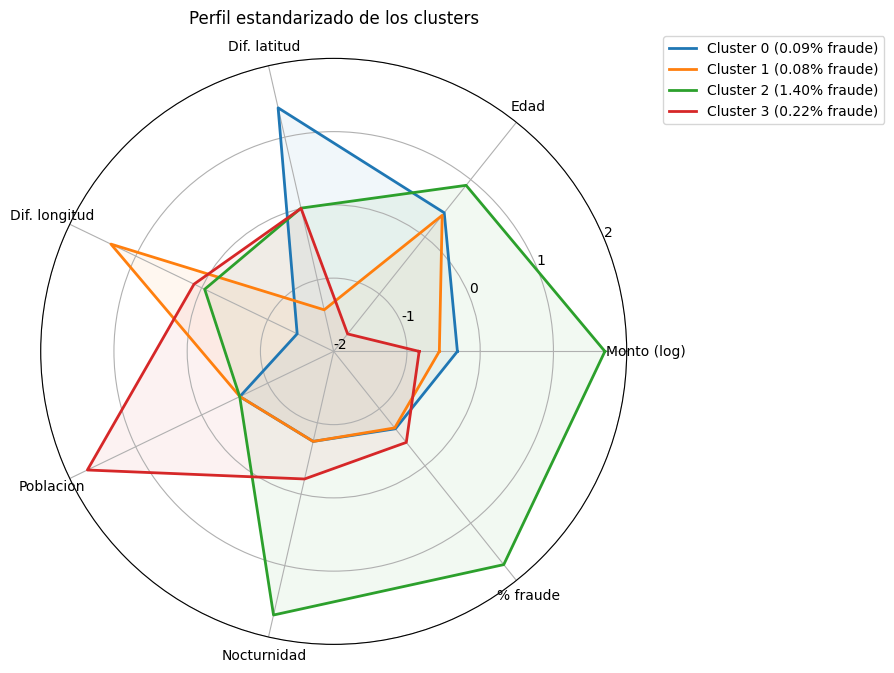

In [89]:
# Perfil promedio de cada cluster
perfil_clusters = scaled_data.copy()
perfil_clusters['cluster'] = labels
perfil_clusters = perfil_clusters.groupby('cluster').mean()


# Agregamos el porcentaje de fraude de cada cluster
fraude_pct = pd.Series(df['is_fraud'].values).groupby(labels).mean() * 100
perfil_clusters['% fraude'] = fraude_pct

# Estandarizamos los perfiles para compararlos en la misma escala
perfil_std = pd.DataFrame(
    StandardScaler().fit_transform(perfil_clusters),
    index=perfil_clusters.index,
    columns=[
        'Monto (log)', 'Edad', 
        'Dif. latitud', 'Dif. longitud',
        'Poblacion', 'Nocturnidad', '% fraude'
    ]
)

variables = perfil_std.columns.tolist()
angulos = np.linspace(0, 2 * np.pi, len(variables), endpoint=False).tolist()
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'polar': True})

for cluster, fila in perfil_std.iterrows():
    # Sumamos 2 para poder repesentar los valores negativos en el radar
    valores = (fila + 2).tolist()
    valores += valores[:1]

    ax.plot(
        angulos, valores, linewidth=2,
        label=f'Cluster {cluster} ({fraude_pct.loc[cluster]:.2f}% fraude)'
    )
    ax.fill(angulos, valores, alpha=0.06)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(variables)
ax.set_ylim(0, 4)
ax.set_yticks([0, 1, 2, 3, 4])
ax.set_yticklabels(['-2', '-1', '0', '1', '2'])
ax.set_title('Perfil estandarizado de los clusters', pad=25)
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1.05))
plt.tight_layout()
plt.show()

El análisis permitió identificar cuatro perfiles de transacciones diferentes sin utilizar previamente la variable de fraude. El grupo más relevante es el cluster 1, caracterizado principalmente por operaciones nocturnas, montos más altos y clientes de mayor edad. Este cluster presenta una tasa de fraude del 2,08 %, considerablemente superior a la del resto de los grupos y aproximadamente 3,6 veces mayor que la tasa general.

El cluster 0 se diferencia por concentrar operaciones asociadas a ciudades con mayor población y presenta una tasa de fraude cercana al promedio general. Por su parte, los clusters 2 y 3 corresponden principalmente a operaciones diurnas y tienen tasas de fraude muy bajas. La diferencia entre ellos parece estar relacionada sobre todo con las variables geográficas: el cluster 2 presenta mayores diferencias de latitud, mientras que el cluster 3 se distingue por mayores diferencias de longitud.

En conclusión, los clusters parecen representar perfiles operativos y geográficos más que grupos de fraude claramente separados. Sin embargo, el cluster 1 demuestra que el análisis no supervisado puede ser útil como herramienta de preselección, ya que permite identificar un conjunto de operaciones con una concentración de fraude superior al promedio. De todos modos, pertenecer a este grupo no implica que una transacción sea fraudulenta: solamente indica que comparte características con un perfil que podría justificar una revisión más detallada.